In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from hirank import RankOD

import time
import warnings

In [2]:
# Define methods
rank = RankOD(mode="rank")
sun = RankOD(mode = "sun")
lof_ball = LocalOutlierFactor(novelty=True, algorithm="ball_tree")
lof_kd = LocalOutlierFactor(novelty=True, algorithm="kd_tree")
iso = IsolationForest()
methods = [rank, sun, lof_ball, lof_kd, iso]
method_names = ["Rank", "Sun", "LOF Ball", "LOF KD", "ISO"]

# Test Scaling with respect to dimension

In [3]:
dimensions = np.linspace(2, 500, 5, dtype="int")
REPEAT = 10

# Warm cache
for method in methods:
    X = np.random.random((100, 30))
    X_test = np.random.random((100, 30))
    with warnings.catch_warnings() as caught:
        warnings.simplefilter("ignore", category=UserWarning)
        method.fit(X)
        method.predict(X_test)

results = []
for d, dim in enumerate(dimensions):
    for r in range(REPEAT):
        X_train, y_train = make_blobs(n_samples=10000, centers=30, n_features=dim)
        X_test, y_test = make_blobs(n_samples=1000, centers=5, n_features=dim)
        for m, method in enumerate(methods):
            print(f"Dimension {dim} ({d+1} of {len(dimensions)} options), Iteration {r}, Method {method_names[m]}")
            start = time.perf_counter()
            method.fit(X_train)
            end = time.perf_counter()
            fit_time = end - start

            start = time.perf_counter()
            method.predict(X_test)
            end = time.perf_counter()
            pred_time = end - start

            results.append([method_names[m], dim, r, fit_time, pred_time])

df = pd.DataFrame(results, columns=["Method", "Dimension", "Iteration", "Fit Time", "Predict Time"])
df

Dimension 2 (1 of 5 options), Iteration 0, Method Rank
Dimension 2 (1 of 5 options), Iteration 0, Method Sun
Dimension 2 (1 of 5 options), Iteration 0, Method LOF Ball
Dimension 2 (1 of 5 options), Iteration 0, Method LOF KD
Dimension 2 (1 of 5 options), Iteration 0, Method ISO
Dimension 2 (1 of 5 options), Iteration 1, Method Rank
Dimension 2 (1 of 5 options), Iteration 1, Method Sun
Dimension 2 (1 of 5 options), Iteration 1, Method LOF Ball
Dimension 2 (1 of 5 options), Iteration 1, Method LOF KD
Dimension 2 (1 of 5 options), Iteration 1, Method ISO
Dimension 2 (1 of 5 options), Iteration 2, Method Rank
Dimension 2 (1 of 5 options), Iteration 2, Method Sun
Dimension 2 (1 of 5 options), Iteration 2, Method LOF Ball
Dimension 2 (1 of 5 options), Iteration 2, Method LOF KD
Dimension 2 (1 of 5 options), Iteration 2, Method ISO
Dimension 2 (1 of 5 options), Iteration 3, Method Rank
Dimension 2 (1 of 5 options), Iteration 3, Method Sun
Dimension 2 (1 of 5 options), Iteration 3, Method LOF 

,Method,Dimension,Iteration,Fit Time,Predict Time
0,Rank,2,0,0.932142,0.861008
1,Sun,2,0,1.048293,0.699280
2,LOF Ball,2,0,0.072753,0.005609
3,LOF KD,2,0,0.026131,0.003578
4,ISO,2,0,0.076471,0.006862
...,...,...,...,...,...
245,Rank,500,9,1.381925,0.731201
246,Sun,500,9,1.392592,0.763444
247,LOF Ball,500,9,21.311177,5.467528
248,LOF KD,500,9,4.910252,7.279641


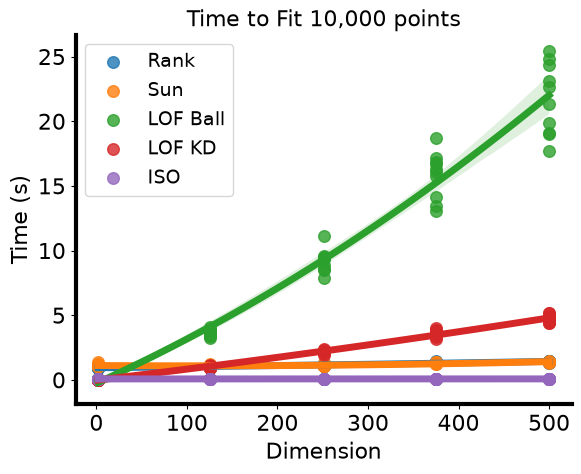

In [5]:
fig, ax = plt.subplots()
for method in method_names:
    sns.regplot(df[df["Method"] == method], x="Dimension", y="Fit Time", order=2, scatter_kws={"s": 70}, line_kws={"linewidth": 5}, label=method, ax=ax)
ax.legend(fontsize=14)
ax.set_title("Time to Fit 10,000 points", fontsize=16)
ax.set_ylabel("Time (s)", fontsize=16)
ax.set_xlabel("Dimension", fontsize=16)
ax.tick_params(labelsize=16)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(3)
plt.savefig("timing_d_fit.pdf")

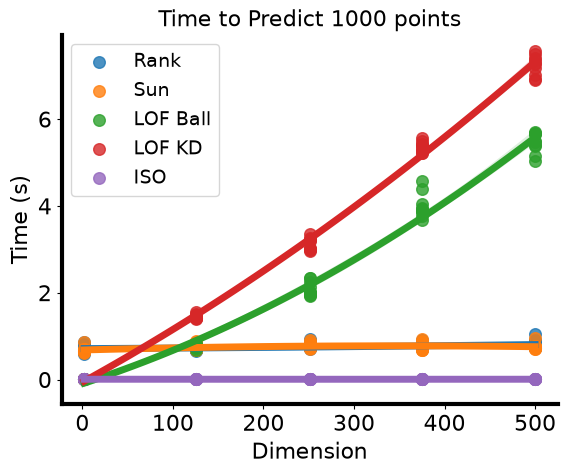

In [6]:
fig, ax = plt.subplots()
for method in method_names:
    sns.regplot(df[df["Method"] == method], x="Dimension", y="Predict Time", order=2, scatter_kws={"s": 70}, line_kws={"linewidth": 5}, label=method, ax=ax)
ax.legend(fontsize=14)
ax.set_title("Time to Predict 1000 points", fontsize=16)
ax.set_ylabel("Time (s)", fontsize=16)
ax.set_xlabel("Dimension", fontsize=16)
ax.tick_params(labelsize=16)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(3)
plt.savefig("timing_d_pred.pdf")

# Scaling with respect to dataset size

In [4]:
sizes = np.linspace(5000, 50000, 5, dtype="int")
dim = 16
REPEAT = 10

# Warm cache
for method in methods:
    X = np.random.random((100, 30))
    X_test = np.random.random((100, 30))
    with warnings.catch_warnings() as caught:
        warnings.simplefilter("ignore", category=UserWarning)
        method.fit(X)
        method.predict(X_test)

results = []
for n, num in enumerate(sizes):
    for r in range(REPEAT):
        X_train, y_train = make_blobs(n_samples=num, centers=30, n_features=dim)
        X_test, y_test = make_blobs(n_samples=num//10, centers=5, n_features=dim)
        for m, method in enumerate(methods):
            print(f"N {num} ({n+1} of {len(sizes)} options), Iteration {r}, Method {method_names[m]}")
            start = time.perf_counter()
            method.fit(X_train)
            end = time.perf_counter()
            fit_time = end - start

            start = time.perf_counter()
            method.predict(X_test)
            end = time.perf_counter()
            pred_time = end - start

            results.append([str(method_names[m]), num, r, fit_time, pred_time])

df = pd.DataFrame(results, columns=["Method", "N", "Iteration", "Fit Time", "Predict Time"])
df

N 5000 (1 of 5 options), Iteration 0, Method Rank
N 5000 (1 of 5 options), Iteration 0, Method Sun
N 5000 (1 of 5 options), Iteration 0, Method LOF Ball
N 5000 (1 of 5 options), Iteration 0, Method LOF KD
N 5000 (1 of 5 options), Iteration 0, Method ISO
N 5000 (1 of 5 options), Iteration 1, Method Rank
N 5000 (1 of 5 options), Iteration 1, Method Sun
N 5000 (1 of 5 options), Iteration 1, Method LOF Ball
N 5000 (1 of 5 options), Iteration 1, Method LOF KD
N 5000 (1 of 5 options), Iteration 1, Method ISO
N 5000 (1 of 5 options), Iteration 2, Method Rank
N 5000 (1 of 5 options), Iteration 2, Method Sun
N 5000 (1 of 5 options), Iteration 2, Method LOF Ball
N 5000 (1 of 5 options), Iteration 2, Method LOF KD
N 5000 (1 of 5 options), Iteration 2, Method ISO
N 5000 (1 of 5 options), Iteration 3, Method Rank
N 5000 (1 of 5 options), Iteration 3, Method Sun
N 5000 (1 of 5 options), Iteration 3, Method LOF Ball
N 5000 (1 of 5 options), Iteration 3, Method LOF KD
N 5000 (1 of 5 options), Iteratio

,Method,N,Iteration,Fit Time,Predict Time
0,Rank,5000,0,0.567671,0.714363
1,Sun,5000,0,0.529520,0.569470
2,LOF Ball,5000,0,0.098504,0.013131
3,LOF KD,5000,0,0.041973,0.025207
4,ISO,5000,0,0.067586,0.005485
...,...,...,...,...,...
120,Rank,50000,4,3.409346,0.948496
121,Sun,50000,4,3.451675,1.003838
122,LOF Ball,50000,4,4.306882,0.564850
123,LOF KD,50000,4,1.697859,1.147060


In [5]:
df.to_feather("compare_runtime_n.feather")

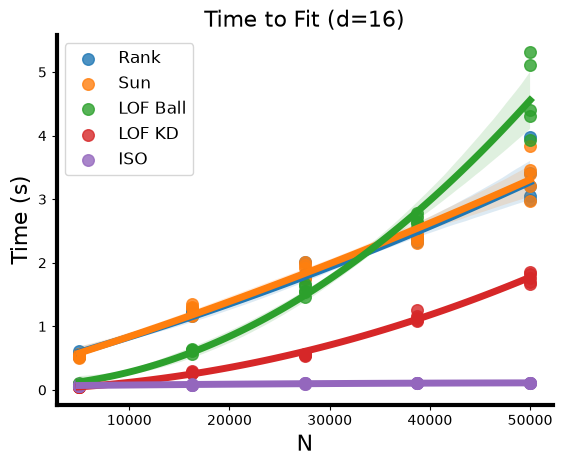

In [12]:
fig, ax = plt.subplots()
for method in method_names:
    sns.regplot(df[df["Method"] == method], x="N", y="Fit Time", order=2, scatter_kws={"s": 70}, line_kws={"linewidth": 5}, label=method, ax=ax)
ax.legend(fontsize=14)
ax.set_title(f"Time to Fit (d={dim})", fontsize=16)
ax.set_ylabel("Time (s)", fontsize=16)
ax.set_xlabel("N", fontsize=16)
ax.tick_params(labelsize=16)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(3)
plt.savefig("timing_n_fit.pdf")

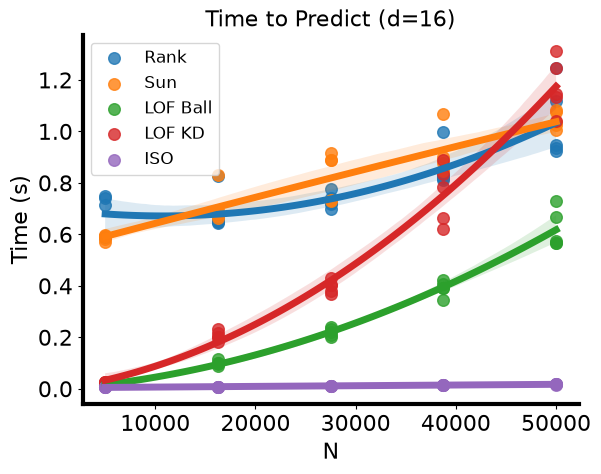

In [13]:
fig, ax = plt.subplots()
for method in method_names:
    sns.regplot(df[df["Method"] == method], x="N", y="Predict Time", order=2, scatter_kws={"s": 70}, line_kws={"linewidth": 5}, label=method, ax=ax)
ax.legend(fontsize=14)
ax.set_title(f"Time to Predict (d={dim})", fontsize=16)
ax.set_ylabel("Time (s)", fontsize=16)
ax.set_xlabel("N", fontsize=16)
ax.tick_params(labelsize=16)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(3)
plt.savefig("timing_n_pred.pdf")